<a href="https://colab.research.google.com/github/ProfessorPatrickSlatraigh/CIS3120-BMWB/blob/main/CIS3120_Mod08_UnitTesting_Class14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CIS3120 — Module 08: Unit Testing in Python

*by Professor Patrick — Spring 2026*

**Course:** CIS 3120 Programming for Analytics  
**Section:** BMWB · Baruch College, Zicklin School of Business  
**Class:** 14 · Monday March 16, 2026  

**Textbook Reference:** [Python Docs — unittest](https://docs.python.org/3/library/unittest.html) · [Real Python — Getting Started with Testing](https://realpython.com/python-testing/)  
**Module:** 08 — Unit Testing

<i>a copy of this notebook is available online at [bit.ly/cis3120class14](https://bit.ly/cis3120class14)</i>

---


### Learning Objectives

By the end of this session you will be able to:

1. Explain what a unit test is and why automated testing matters for analytics code.
2. Write test cases using Python's `unittest` framework.
3. Use `setUp` and `tearDown` to manage shared test state.
4. Run a test suite and interpret pass, fail, and error output.
5. Apply the test-driven development (TDD) Red → Green → Refactor cycle.

---

### Session Map

| Part | Topic | Type |
|:---|:---|:---|
| 1 | Why Test? | Concept + discussion |
| 2 | The `unittest` Framework | Demonstration |
| 3 | Test-Driven Development (TDD) | Guided walkthrough |
| 4 | Practice | Scaffolded exercises |
| Appendix | Unit Testing and the GitHub Workflow | Reference / self-study |

---


---
## Part 1 — Why Test?

---


### 1.1 The Problem with Manual Testing

When you finish writing a function, you probably run it a few times and check that the output looks right. That works in the moment — but it does not protect you from what happens next:

- You modify the function three weeks later and forget to recheck all the edge cases.
- A teammate changes code your function depends on.
- The function works on your dataset but fails silently on slightly different data.

**Automated tests** solve this. You write the verification once. It runs in milliseconds every time anyone touches the code.

In professional environments, code without tests is treated as incomplete — in the same way that a function without a docstring or a commit without a message is incomplete.


### 1.2 What is a Unit Test?

A **unit test** verifies that one small, isolated piece of code — typically one function or one method — behaves correctly for a given input.

The word *unit* means the smallest independently testable piece of behavior. A good unit test has four properties:

| Property | What it means |
|:---|:---|
| **Isolated** | Does not depend on external state, other functions, or a database |
| **Repeatable** | Produces the same result every time it runs |
| **Fast** | Executes in milliseconds |
| **Self-describing** | Its name states exactly what it verifies |




---



### 1.3 Discussion

Consider this PIN validator — a simplified version of the validation logic that would guard inserts into the `COMMON_PINS` database from Module 07:

```python
def is_valid_pin(pin):
    return len(pin) == 4 and pin.isdigit()
```

Before writing any test code, think through these questions and record your answers as comments below.


In [ ]:
# Discussion — think through these before we move on:
#
# 1. What inputs should this function return True for?
#
#
# 2. What inputs should it return False for?
#
#
# 3. What edge cases might catch a buggy implementation?
#    (Think: empty string, None, an integer, spaces, letters, too long, too short)


---
## Part 2 — The `unittest` Framework

---


### 2.1 Anatomy of a Test Case

Python's `unittest` module is part of the standard library — no installation required. Three concepts cover everything you need today:

**`TestCase`** — a class you subclass. Every method whose name starts with `test_` is automatically treated as a test.

**Assertion methods** — `self.assertEqual()`, `self.assertTrue()`, etc. These are how you state what you expect. If the assertion is not satisfied, the test fails and `unittest` reports the exact line that failed.

**Test runner** — `unittest.TextTestRunner` discovers and runs the tests and prints a report. In a Colab notebook we use `TextTestRunner` directly; at the command line you would run `python -m unittest filename.py`.




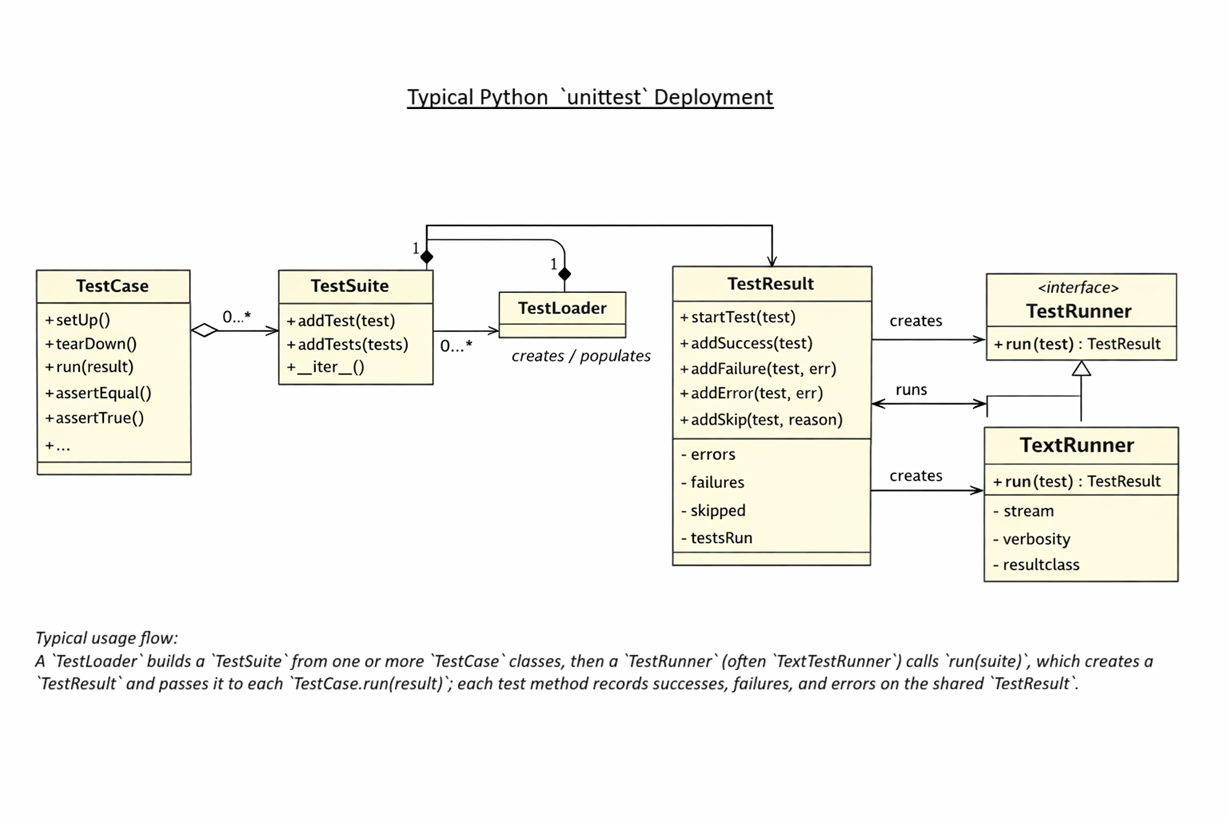

The cells below defines a minimal but complete test case. Run it and read every line of output before moving on.

In [ ]:
# ── The function under test ───────────────────────────────────────────────────
print("\nDefined function `isvalid_pin()`...")
def is_valid_pin(pin):
    """Return True if pin is a 4-digit string of digits, False otherwise."""
    return isinstance(pin, str) and len(pin) == 4 and pin.isdigit()


In [ ]:
import unittest

# ── The test case ─────────────────────────────────────────────────────────────
print("\nDefined Class `TestIsValidPin()` with test case assertions...")
class TestIsValidPin(unittest.TestCase):

    def test_valid_pin(self):
        """A 4-digit string of digits should return True."""
        self.assertTrue(is_valid_pin('1234'))

    def test_too_short(self):
        """A 3-digit string should return False."""
        self.assertFalse(is_valid_pin('123'))

    def test_non_numeric(self):
        """A 4-character non-numeric string should return False."""
        self.assertFalse(is_valid_pin('abcd'))

    def test_empty(self):
        """An empty string should return False."""
        self.assertFalse(is_valid_pin(''))



In [ ]:
# ── Run the suite ─────────────────────────────────────────────────────────────
# verbosity=2 prints one line per test method instead of one dot per test.
print("\nExecution of TextTestRunner with verbosity=2 to create `runner`...")
runner = unittest.TextTestRunner(verbosity=2)

print("\nExecution of TestLoader with TestCase loaded from `TestIsValidPin` to create `suite`...")
suite  = unittest.TestLoader().loadTestsFromTestCase(TestIsValidPin)

print("\nExecution of `.run(suite)` on object `runner` follows...")
runner.run(suite)

**Reading the output:**

| Symbol | Meaning |
|:---|:---|
| `ok` (verbosity=2) or `.` | Test passed |
| `FAIL` or `F` | Assertion was not satisfied |
| `ERROR` or `E` | An unexpected exception was raised before the assertion |
| `SKIP` or `S` | Test was deliberately skipped |

`OK` at the end means every test in the suite passed. Any failure appears as `FAILED (failures=N)`.


In section 2.1 above, the following terms and variables are used to build a unit test:

#### Core Framework Terms

* **`unittest`**: Python’s built-in standard library for creating and running automated tests.
* **TestCase**: A class you "subclass" (inherit from) to create a group of related tests. In the notebook, `TestIsValidPin` is a subclass of `unittest.TestCase`.
* **Assertion methods**: Specialized methods provided by the `TestCase` class to check if a condition is true. If the condition is not met, the test fails.
* **Test Runner**: The engine that discovers, executes the test methods, and provides the final report (pass/fail).

#### Variable and Method Names in the Code

* **`is_valid_pin(pin)`**: This is the **function under test**. It takes one variable, `pin`, and returns `True` if it meets specific criteria (4 digits) or `False` if it doesn't.
* **`TestIsValidPin`**: The variable name for the class that contains all the tests for the pin validator.
* **`test_` (prefix)**: Any method inside the test class that starts with `test_` (e.g., `test_too_short`) is automatically identified by the framework as a test to be run.
* **`self.assertTrue()`**: An assertion variable/method that expects the value inside the parentheses to be `True`.
* **`self.assertFalse()`**: An assertion variable/method that expects the value inside the parentheses to be `False`.
* **`runner`**: A variable assigned to `unittest.TextTestRunner(verbosity=2)`. It is responsible for executing the suite and printing the detailed results.
* **`suite`**: A variable that holds a collection of tests loaded from the `TestIsValidPin` class using `unittest.TestLoader()`.
* **`verbosity=2`**: A setting passed to the runner that tells it to print a detailed, one-line report for every individual test method instead of just a simple dot.

#####<font color=blue><b>REMEMBER: `test_` Prefix~</b></font>

<font color=blue><i>The prefix `test_` has special meaning. Any method inside the <b>test class</b> that starts with `test_` is automatically identified by the Python `unittest` framework as a <b>test</b> to be run.</i></font>   



---



### 2.2 Assertion Methods

The table below lists every assertion method you will use in this course.

| Method | Passes when… |
|:---|:---|
| `assertEqual(a, b)` | `a == b` |
| `assertNotEqual(a, b)` | `a != b` |
| `assertTrue(x)` | `bool(x) is True` |
| `assertFalse(x)` | `bool(x) is False` |
| `assertIsNone(x)` | `x is None` |
| `assertIsNotNone(x)` | `x is not None` |
| `assertIn(a, b)` | `a in b` |
| `assertRaises(Exc, callable, *args)` | `callable(*args)` raises `Exc` |

All of them accept an optional `msg=` keyword argument. When the assertion fails, `msg` is printed alongside the traceback — useful for diagnosing failures when the values alone are ambiguous.

The cell below demonstrates several of these methods together.


In [ ]:
import unittest

class TestAssertionMethods(unittest.TestCase):

    def test_assertEqual(self):
        self.assertEqual(2 + 2, 4)

    def test_assertTrue(self):
        self.assertTrue('hello'.isupper() is False)

    def test_assertFalse(self):
        self.assertFalse(0 == 1)

    def test_assertIsNone(self):
        result = None
        self.assertIsNone(result)

    def test_assertIn(self):
        self.assertIn('b', ['a', 'b', 'c'])

    def test_assertRaises(self):
        # The with-block form is the cleanest way to test for exceptions.
        with self.assertRaises(ValueError):
            int('not_a_number')

    def test_assertEqual_with_msg(self):
        x = 5
        self.assertEqual(x, 5, msg=f'Expected 5 but got {x}')


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestAssertionMethods)
runner.run(suite)


The following methods aee defned in the code block above.

| Method Name | Use / Description |  
|-------------|-------------------|    
| assertEqual(a, b) | Checks if two values are equal ($a == b$). If they are not, the test fails. |  
| assertTrue(x) | Checks if the expression $x$ evaluates to True. |
|assertFalse(x) | Checks if the expression $x$ evaluates to False. |  
| assertIsNone(x) | Checks if a variable is exactly None. |
assertIn(member, container) | Checks if an item exists within a list, string, or other collection (member in container). |  
| assertRaises(Exception) | Used as a context manager (with the with keyword) to verify that a specific block of code triggers a certain rror, such as a ValueError. |  



---



### 2.3 `setUp` and `tearDown`

When multiple test methods need the same starting state — for example, a freshly created `Account` object — repeating the setup code inside every method is verbose and fragile.

`setUp()` runs **before every test method**. `tearDown()` runs **after every test method**, even when the test failed. Together they guarantee that each test starts from a clean, independent state — no test can accidentally corrupt the state seen by another.


In [ ]:
# ── Re-use the Account class from Module 05 ───────────────────────────────────
class Account:
    """A simplified bank account (Module 05)."""

    def __init__(self, owner='No Name', balance=0):
        self.owner   = owner
        self.balance = balance

    def deposit(self, amount):
        if amount > 0:
            self.balance += amount

    def withdraw(self, amount):
        if amount > self.balance:
            return 'NSF'
        elif amount > 0:
            self.balance -= amount
            return self.balance

    def __str__(self):
        return f'Account[{self.owner}] ${self.balance:.2f}'

In [ ]:
import unittest

class TestAccount(unittest.TestCase):

    def setUp(self):
        """Create a fresh Account before each test method."""
        # Every test below starts with Alice's account at $100.
        self.acct = Account('Alice', 100)

    # No tearDown needed here — there is nothing to close or clean up.

    def test_initial_balance(self):
        """Constructor should set the balance correctly."""
        self.assertEqual(self.acct.balance, 100)

    def test_deposit_increases_balance(self):
        """A valid deposit should increase the balance by the deposit amount."""
        self.acct.deposit(50)
        self.assertEqual(self.acct.balance, 150)

    def test_withdraw_decreases_balance(self):
        """A valid withdrawal should reduce the balance correctly."""
        self.acct.withdraw(30)
        self.assertEqual(self.acct.balance, 70)

    def test_overdraft_returns_nsf(self):
        """A withdrawal exceeding the balance should return the string 'NSF'."""
        result = self.acct.withdraw(200)
        self.assertEqual(result, 'NSF')

    def test_overdraft_does_not_change_balance(self):
        """A failed withdrawal should leave the balance unchanged."""
        self.acct.withdraw(200)
        self.assertEqual(self.acct.balance, 100)


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestAccount)
runner.run(suite)


Notice that `test_withdraw_decreases_balance` is not affected by the deposit in `test_deposit_increases_balance`. Because `setUp` creates a brand-new `Account` before every method, the tests are completely independent regardless of the order in which `unittest` runs them.




---



### 2.4 Deliberately Failing a Test

Understanding failure output is as important as making tests pass. The cell below contains an intentional bug. Run it, read the failure message carefully, then fix the bug in the next cell.


In [ ]:
# ── Buggy implementation ──────────────────────────────────────────────────────
def is_valid_pin_buggy(pin):
    """Buggy: only checks length, ignores whether the characters are digits."""
    return len(pin) == 4     # <-- intentional bug

In [ ]:
import unittest

class TestBuggyPin(unittest.TestCase):

    def test_valid_pin(self):
        self.assertTrue(is_valid_pin_buggy('1234'))   # passes

    def test_non_numeric_should_fail(self):
        """This test exposes the bug."""
        self.assertFalse(is_valid_pin_buggy('abcd'))  # FAILS


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestBuggyPin)
runner.run(suite)


The failure output will contain a line like:

```
AssertionError: True is not false
```

This tells you precisely: `is_valid_pin_buggy('abcd')` returned `True` when the test expected `False`. That points directly at the missing `.isdigit()` check.

Fix the bug in the cell below and re-run to confirm both tests pass.


In [ ]:
# TODO: Fix the bug in this implementation
def is_valid_pin_fixed(pin):
    return len(pin) == 4     # <-- fix this line


In [ ]:
import unittest

class TestFixedPin(unittest.TestCase):

    def test_valid_pin(self):
        self.assertTrue(is_valid_pin_fixed('1234'))

    def test_non_numeric(self):
        self.assertFalse(is_valid_pin_fixed('abcd'))


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestFixedPin)
runner.run(suite)


---
## Part 3 — Test-Driven Development (TDD)

---


### 3.1 The Red → Green → Refactor Cycle

Test-driven development (TDD) inverts the usual order of work:

1. **Red** — Write a test for behavior that does not exist yet. Run it. It must fail. If it passes without any implementation, the test is not testing anything real.
2. **Green** — Write the minimum code that makes the test pass. Do not over-engineer.
3. **Refactor** — Clean up the code. Your passing tests confirm that the cleanup broke nothing.
4. Repeat for the next behavior.

Writing the test first forces you to think clearly about *what* a function must do before thinking about *how* to implement it. This usually leads to simpler, more focused implementations.




---



### 3.2 Walkthrough — `count_words()`

We will build a function that counts the number of words in a string, step by step.

**Step 1 — Red:** Write one test for the simplest case. Run it. It must fail (the function does not exist).


In [ ]:
import unittest

# Step 1: write the test FIRST — count_words() does not exist yet.

class TestCountWords(unittest.TestCase):

    def test_single_word(self):
        """A single-word string should return 1."""
        self.assertEqual(count_words('hello'), 1)     # NameError expected

runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestCountWords)
runner.run(suite)

# Expected output: ERROR  (NameError: name 'count_words' is not defined)
# This is the RED step. The error confirms the test is actually testing something.


**Step 2 — Green:** Write the minimum implementation that makes the test pass.


In [ ]:
import unittest

def count_words(text):
    """Return the number of words in text."""
    return len(text.split())


class TestCountWords(unittest.TestCase):

    def test_single_word(self):
        self.assertEqual(count_words('hello'), 1)

runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestCountWords)
runner.run(suite)

# Expected output: OK — GREEN step complete.


**Step 3 — Expand:** Add more tests. Each may pass immediately (the implementation already handles it) or expose a gap. Either outcome is useful.


In [ ]:
import unittest

def count_words(text):
    """Return the number of words in text."""
    return len(text.split())


class TestCountWords(unittest.TestCase):

    def test_single_word(self):
        self.assertEqual(count_words('hello'), 1)

    def test_multiple_words(self):
        self.assertEqual(count_words('the quick brown fox'), 4)

    def test_empty_string(self):
        """An empty string contains zero words."""
        self.assertEqual(count_words(''), 0)

    def test_extra_whitespace(self):
        """Multiple spaces between words should not inflate the count."""
        self.assertEqual(count_words('  hello   world  '), 2)

    def test_single_character(self):
        self.assertEqual(count_words('a'), 1)


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestCountWords)
runner.run(suite)


All five tests pass without modifying `count_words()` — `str.split()` handles extra whitespace and empty strings by default. This is a common TDD outcome: a well-chosen minimal implementation satisfies multiple tests naturally.

The cycle for this function is complete: **Red → Green → (no refactoring needed) → done.**

---


---
## Part 4 — Practice

---


### Exercise 1 — `is_valid_pin()` Test Suite

**Scenario:** The Module 07 `COMMON_PINS` database stores commonly used ATM PINs. Before a new PIN can be inserted it must be validated. You have been asked to write the validator and a complete test suite for it.

**Specification for `is_valid_pin(pin)`:**
- Returns `True` if and only if `pin` is a string of exactly four digits (`0`–`9`).
- Returns `False` for everything else: too short, too long, contains letters or spaces, is `None`, is an integer, etc.
- Must not raise an exception for any input.

**Your tasks:**
1. Implement `is_valid_pin(pin)` in the cell below.
2. Fill in each `# TODO` test method.
3. Run the suite and confirm all 8 tests pass.


In [ ]:
import unittest

# ── TODO 1: Implement is_valid_pin ────────────────────────────────────────────
def is_valid_pin(pin):
    """Return True if pin is a 4-digit string of digits, False otherwise."""
    # Hints:
    #   isinstance(pin, str) guards against non-string input without crashing.
    #   len(pin) == 4 checks the length.
    #   pin.isdigit() checks that every character is a digit.
    pass   # replace this line with your implementation


# ── TODO 2: Complete each test method ────────────────────────────────────────
class TestIsValidPin(unittest.TestCase):

    def test_valid_1234(self):
        """Classic bad PIN 1234 should pass the format check."""
        # TODO: assert is_valid_pin('1234') returns True
        pass

    def test_valid_0000(self):
        """0000 is a valid 4-digit format."""
        # TODO: assert is_valid_pin('0000') returns True
        pass

    def test_too_short(self):
        """A 3-digit string is too short."""
        # TODO: assert is_valid_pin('123') returns False
        pass

    def test_too_long(self):
        """A 5-digit string is too long."""
        # TODO: assert is_valid_pin('12345') returns False
        pass

    def test_non_numeric(self):
        """A 4-character alphabetic string should return False."""
        # TODO: assert is_valid_pin('abcd') returns False
        pass

    def test_empty_string(self):
        """An empty string should return False."""
        # TODO: assert is_valid_pin('') returns False
        pass

    def test_with_spaces(self):
        """A string containing a space should return False."""
        # TODO: assert is_valid_pin('12 4') returns False
        pass

    def test_integer_input(self):
        """An integer (not a string) should return False without raising an exception."""
        # TODO: assert is_valid_pin(1234) returns False
        pass


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestIsValidPin)
runner.run(suite)


---

### Exercise 2 — `Account` Class Test Suite

**Scenario:** You built the `Account` class in Module 05. Now write a full test suite for it using `setUp`, a range of assertion methods, and multiple edge cases.

The `Account` class is reproduced below — do not modify it.

**Your tasks:**
1. Implement `setUp` to create a fresh account before each test.
2. Fill in each `# TODO` test method.
3. Run the suite and confirm all 9 tests pass.


In [ ]:
import unittest

# ── Account class — do not modify ─────────────────────────────────────────────
class Account:
    def __init__(self, owner='No Name', balance=0):
        self.owner   = owner
        self.balance = balance

    def deposit(self, amount):
        if amount > 0:
            self.balance += amount

    def withdraw(self, amount):
        if amount > self.balance:
            return 'NSF'
        elif amount > 0:
            self.balance -= amount
            return self.balance

    def __str__(self):
        return f'Account[{self.owner}] ${self.balance:.2f}'


# ── TODO: Complete the test class ────────────────────────────────────────────
class TestAccount(unittest.TestCase):

    def setUp(self):
        # TODO: create self.acct as Account('Test User', 200)
        pass

    def test_initial_balance(self):
        # TODO: assert balance equals 200
        pass

    def test_initial_owner(self):
        # TODO: assert owner equals 'Test User'
        pass

    def test_deposit_increases_balance(self):
        # TODO: deposit 50, then assert balance equals 250
        pass

    def test_deposit_zero_no_change(self):
        # TODO: deposit 0, then assert balance is still 200
        pass

    def test_withdraw_decreases_balance(self):
        # TODO: withdraw 75, then assert balance equals 125
        pass

    def test_overdraft_returns_nsf(self):
        # TODO: withdraw 500 and assert the return value equals 'NSF'
        pass

    def test_overdraft_balance_unchanged(self):
        # TODO: withdraw 500, then assert balance is still 200
        pass

    def test_multiple_transactions(self):
        # TODO: deposit 100, withdraw 50, deposit 25 -> assert balance equals 275
        pass

    def test_str_contains_owner_and_balance(self):
        # TODO: assert str(self.acct) contains 'Test User'
        #       and also contains '200'
        # Hint: use assertIn twice
        pass


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestAccount)
runner.run(suite)


---

### Stretch Exercise — `clean_price()` using TDD

**Scenario:** A data pipeline receives price values scraped from a website as raw strings such as `'$12.99'`, `'  5.00  '`, and `'USD 7.50'`. You need a function `clean_price(raw)` that returns a `float`, or raises `ValueError` if the value cannot be converted.

Follow the TDD cycle:

1. Write one test. Run it — it must fail.
2. Write the minimum implementation to make it pass.
3. Add the next test. Repeat.

Work through the steps in the cells below.


In [ ]:
import unittest
import re

# ── Step 1 RED: write the first test before implementing anything ──────────────
class TestCleanPrice(unittest.TestCase):

    def test_dollar_sign(self):
        """'$12.99' should return the float 12.99."""
        self.assertAlmostEqual(clean_price('$12.99'), 12.99)

runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestCleanPrice)
runner.run(suite)
# Expected: ERROR (NameError) — RED step confirmed.


In [ ]:
import unittest
import re

# ── Step 2 GREEN: minimum implementation ─────────────────────────────────────
def clean_price(raw):
    """Extract a float from a raw price string, or raise ValueError."""
    # TODO: implement
    # Hint: re.sub(r'[^0-9.]', '', raw) strips everything except digits and dots.
    # Hint: if the result is empty after stripping, raise ValueError.
    pass


class TestCleanPrice(unittest.TestCase):

    def test_dollar_sign(self):
        self.assertAlmostEqual(clean_price('$12.99'), 12.99)

    # ── Add more tests here as you expand the implementation ──────────────────

    def test_leading_trailing_spaces(self):
        # TODO: assert clean_price('  5.00  ') returns 5.0
        pass

    def test_currency_prefix(self):
        # TODO: assert clean_price('USD 7.50') returns 7.5
        pass

    def test_non_numeric_raises(self):
        # TODO: assert clean_price('free') raises ValueError
        pass

    def test_none_raises(self):
        # TODO: assert clean_price(None) raises ValueError
        pass


runner = unittest.TextTestRunner(verbosity=2)
suite  = unittest.TestLoader().loadTestsFromTestCase(TestCleanPrice)
runner.run(suite)


---
## Summary

| Concept | Key syntax |
|:---|:---|
| Define a test case | `class MyTest(unittest.TestCase):` |
| Write a test method | `def test_something(self):` |
| Assert equality | `self.assertEqual(actual, expected)` |
| Assert truthiness | `self.assertTrue(x)` / `self.assertFalse(x)` |
| Assert exception | `with self.assertRaises(ExcType):` |
| Shared setup | `def setUp(self):` — runs before every test method |
| Run the suite | `unittest.TextTestRunner(verbosity=2).run(suite)` |
| TDD cycle | Red → Green → Refactor |


---

## Resources

| Resource | URL |
|:---|:---|
| Python `unittest` documentation | https://docs.python.org/3/library/unittest.html |
| Real Python — Getting Started with Testing | https://realpython.com/python-testing/ |
| Runestone FOPP | https://runestone.academy/ns/books/published/fopp/ |
| practical_db (SQL reference) | https://runestone.academy/ns/books/published/practical_db/ |

---


**Next session — Wednesday March 18: Midterm Review**  
The midterm on Monday March 23 covers Modules 01 through 08 (Python fundamentals through Unit Testing). Bring questions Wednesday.

---
## Appendix — Unit Testing and the GitHub Workflow

*This section is for reference and self-study. It will not appear on the March 23 midterm.*

---

### A.1 Where Tests Live in a Repository

Tests belong in the same repository as the code they test, committed alongside every change.

```
my_project/
├── account.py              # source code
├── pin_validator.py        # source code
├── test_account.py         # tests for account.py
└── test_pin_validator.py   # tests for pin_validator.py
```

Running `python -m unittest discover` from the project root automatically finds and runs every file matching `test_*.py`.

---

### A.2 Tests in the Branch Workflow

1. Create a feature branch: `git checkout -b add-pin-validator`
2. Write the function **and** its tests on the same branch.
3. Run the tests locally: `python -m unittest discover`
4. Commit both source and test files together.
5. Push and open a pull request.
6. A reviewer checks both the implementation and the tests before merging.

A pull request that introduces new code without tests is incomplete. A pull request whose tests fail should not be merged.

---

### A.3 Connecting to Mini-Project 01 (CodingGrace)

Each room function in `CodingGraceGame.py` follows a contract: accept `player_info_arg`, update the dictionary, call `show_player_info()`, and return either the updated dictionary or the string `'flee'`. These requirements are directly testable.

A minimal test for a room function would:

1. Create a mock `player_info` dictionary in `setUp`.
2. Call the room function with that dictionary.
3. Assert that `player_info['location']` was updated to the room name.
4. Assert that the room name was appended to `player_info['choices']`.

Mocking `input()` to avoid interactive prompts during testing is an advanced pattern covered in later courses, but the assertion logic is exactly the same as everything you practised today.
